# This is a notebook for A/E analysis on the Scarf Data. It focuses on using different Smooths to try to classify slow pulses using A/E methode

In [18]:
from lgdo import lh5
import os
import awkward as ak
import numpy as np
from matplotlib import pyplot as plt


In [19]:
filepath = "/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs"
files = os.listdir(filepath)
files.sort()
files

['s100ns_mw1',
 's100ns_mw3',
 's100ns_mw5',
 's100ns_mw7',
 's200ns_mw1',
 's200ns_mw3',
 's200ns_mw5',
 's200ns_mw7',
 's60ns_mw1',
 's60ns_mw3',
 's60ns_mw5',
 's60ns_mw7']

## Reading Files

In [22]:
import os
import re

pnum_cal = "00"
run_cal = "037"

pnum_phy_bg = "00"
run_phy_bg = "038"

pnum_phy_signal = "05"
run_phy_signal = "059"

runs = [
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7'
]

def build_run_db(runs, filepath):
    db = {}
    missing = []

    for run in runs:
        m = re.match(r"s(\d+)ns_mw(\d+)", run)
        if not m:
            missing.append(f"{run}: invalid run name format")
            continue

        run_path = os.path.join(filepath, run)

        phy_bg_path = os.path.join(run_path, "phy", f"p{pnum_phy_bg}", f"r{run_phy_bg}")
        phy_signal_path = os.path.join(run_path, "phy", f"p{pnum_phy_signal}", f"r{run_phy_signal}")
        cal_path = os.path.join(run_path, "cal", f"p{pnum_cal}", f"r{run_cal}")

        missing_this_run = []

        if not os.path.exists(run_path):
            missing_this_run.append(f"run folder missing: {run_path}")
        if not os.path.exists(phy_bg_path):
            missing_this_run.append(f"phy_bg path missing: {phy_bg_path}")
        if not os.path.exists(phy_signal_path):
            missing_this_run.append(f"phy_signal path missing: {phy_signal_path}")
        if not os.path.exists(cal_path):
            missing_this_run.append(f"cal path missing: {cal_path}")

        if missing_this_run:
            missing.append(f"{run}\n  " + "\n  ".join(missing_this_run))
            continue

        phy_bg_files = sorted(os.listdir(phy_bg_path))
        phy_signal_files = sorted(os.listdir(phy_signal_path))
        cal_files = sorted(os.listdir(cal_path))

        db[run] = {
            "run": run,
            "interval": f"{m.group(1)}ns",
            "mw": f"mw{m.group(2)}",

            "phy_bg_path": phy_bg_path,
            "phy_signal_path": phy_signal_path,
            "cal_path": cal_path,

            "phy_bg_files": phy_bg_files,
            "phy_signal_files": phy_signal_files,
            "cal_files": cal_files,

            "phy_bg_pathlist": [os.path.join(phy_bg_path, f) for f in phy_bg_files],
            "phy_signal_pathlist": [os.path.join(phy_signal_path, f) for f in phy_signal_files],
            "cal_pathlist": [os.path.join(cal_path, f) for f in cal_files],
        }

    if missing:
        raise FileNotFoundError(
            "[ERROR] Some runs or paths are missing:\n\n" + "\n\n".join(missing)
        )

    return db

In [23]:
run_db = build_run_db(runs, filepath)

print(run_db["s100ns_mw3"].keys())
print(run_db["s100ns_mw3"]["cal_pathlist"][:2])
print(run_db["s100ns_mw3"]["phy_bg_pathlist"][:2])
print(run_db["s100ns_mw3"]["phy_signal_pathlist"][:2])

dict_keys(['run', 'interval', 'mw', 'phy_bg_path', 'phy_signal_path', 'cal_path', 'phy_bg_files', 'phy_signal_files', 'cal_files', 'phy_bg_pathlist', 'phy_signal_pathlist', 'cal_pathlist'])
['/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs/s100ns_mw3/cal/p00/r037/sp01-p00-r037-cal-20231026T180002Z-tier_hit.lh5', '/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs/s100ns_mw3/cal/p00/r037/sp01-p00-r037-cal-20231026T183002Z-tier_hit.lh5']
['/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs/s100ns_mw3/phy/p00/r038/sp01-p00-r038-phy-20231027T170002Z-tier_hit.lh5', '/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs/s100ns_mw3/phy/p00/r038/sp01-p00-r038-phy-20231027T173002Z-tier_hit.lh5']
['/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs/s100ns_mw3/phy/p05/r059/sp01-p05-r059-phy-20240215T103002Z-tier_hit.lh5', '/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs/s100ns_mw3/phy/p05/r059/sp01-p05-r059-phy-20240215T110001Z-tier_hit.lh5']


In [24]:
lh5.show(run_db["s100ns_mw3"]["phy_bg_pathlist"][0])

/
├── ch001 · struct{hit} 
│   └── hit · table{A_max_mw_o_E_Classifier,A_max_mw_o_E_Corrected,A_max_mw_o_E_Double_Sided_Cut,A_max_mw_o_E_High_Side_Cut,A_max_mw_o_E_Low_Cut,A_max_mw_o_E_Timecorr,A_max_mw_o_E_Uncorr,A_max_mw_o_E_fix_Classifier,A_max_mw_o_E_fix_Corrected,A_max_mw_o_E_fix_Double_Sided_Cut,A_max_mw_o_E_fix_High_Side_Cut,A_max_mw_o_E_fix_Low_Cut,A_max_mw_o_E_fix_Timecorr,A_max_mw_o_E_fix_Uncorr,A_max_o_E_Classifier,A_max_o_E_Corrected,A_max_o_E_Double_Sided_Cut,A_max_o_E_High_Side_Cut,A_max_o_E_Low_Cut,A_max_o_E_Timecorr,A_max_o_E_Uncorr,A_max_o_E_fix_Classifier,A_max_o_E_fix_Corrected,A_max_o_E_fix_Double_Sided_Cut,A_max_o_E_fix_High_Side_Cut,A_max_o_E_fix_Low_Cut,A_max_o_E_fix_Timecorr,A_max_o_E_fix_Uncorr,A_max_tri_o_E_Classifier,A_max_tri_o_E_Corrected,A_max_tri_o_E_Double_Sided_Cut,A_max_tri_o_E_High_Side_Cut,A_max_tri_o_E_Low_Cut,A_max_tri_o_E_Timecorr,A_max_tri_o_E_Uncorr,A_max_tri_o_E_fix_Classifier,A_max_tri_o_E_fix_Corrected,A_max_tri_o_E_fix_Double_Sided_Cut,A_max

In [25]:
import awkward as ak

def safe_lh5_read(lh5, key, files):
    out = lh5.read(key, files)
    if isinstance(out, tuple):
        return out[0]
    return out

def get_pathlist(info, dataset):
    if dataset == "cal":
        return info["cal_pathlist"]
    elif dataset == "phy_bg":
        return info["phy_bg_pathlist"]
    elif dataset == "phy_signal":
        return info["phy_signal_pathlist"]
    else:
        raise ValueError(f"[ERROR] unknown dataset: {dataset}")

def read_array_from_run(run_db, run, lh5, dataset="cal", channel="ch001", table="hit", field="trapEftp_cal"):
    if run not in run_db:
        raise KeyError(f"[ERROR] {run} not found in run_db")

    info = run_db[run]
    pathlist = get_pathlist(info, dataset)

    if len(pathlist) == 0:
        raise ValueError(f"[ERROR] {dataset}_pathlist is empty for {run}")

    obj = safe_lh5_read(lh5, f"{channel}/{table}", pathlist)
    ak_obj = obj.view_as("ak")

    return ak.to_numpy(ak_obj[field])

In [26]:
run = "s100ns_mw3"

E_cal_ch1 = read_array_from_run(
    run_db, run, lh5,
    dataset="cal",
    channel="ch001",
    table="hit",
    field="trapEftp_cal"
)

print(E_cal_ch1[:10])
print(len(E_cal_ch1))

[-5.04309142e+00 -2.56841230e+00  6.23416326e+00  1.65251133e+03
  1.18737411e+01 -6.51020046e+00  6.28655059e+02  1.06306099e-01
 -5.04176773e-01 -1.78871139e+00]
2292780


In [28]:
import numpy as np
import matplotlib.pyplot as plt

def plot_field_from_run(run_db, run, lh5,
                        dataset="cal",
                        channel="ch001",
                        table="hit",
                        field="trapEftp_cal",
                        bins=3000,
                        erange=(0, 3000),
                        logy=True):
    arr = read_array_from_run(
        run_db, run, lh5,
        dataset=dataset,
        channel=channel,
        table=table,
        field=field
    )

    hist, edges = np.histogram(arr, bins=bins, range=erange)
    centers = 0.5 * (edges[:-1] + edges[1:])

    plt.figure(figsize=(7, 5))
    plt.step(centers, hist, where="mid")
    if logy:
        plt.yscale("log")
    plt.xlabel(field)
    plt.ylabel("Counts")
    plt.title(f"{run} | {dataset}_{channel}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "counts": hist,
        "edges": edges,
        "centers": centers,
        "n_total": len(arr),
        "run": run,
        "dataset": dataset,
        "channel": channel,
        "field": field,
    }

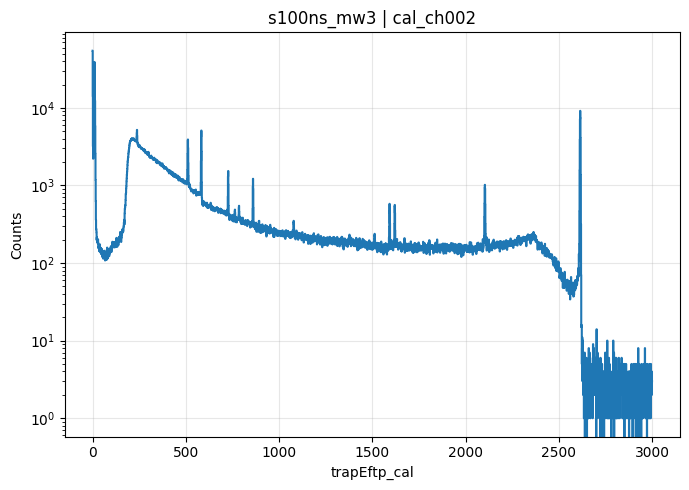

In [32]:
hist_db = plot_field_from_run(
    run_db,
    run="s100ns_mw3",
    lh5=lh5,
    dataset="cal",
    channel="ch002",
    table="hit",
    field="trapEftp_cal",
    bins=3000,
    erange=(0, 3000)
)

## A/E plots

In [34]:
def build_energy_masks_from_run(run_db, run, lh5, channel="ch001",
                                energy_field="trapEftp_cal",
                                dep_min=1587, dep_max=1597,
                                fep_min=2610, fep_max=2620,
                                E_lowerlim=1839, E_upperlim=2239):
    # cal
    E_cal = read_array_from_run(
        run_db, run, lh5,
        dataset="cal",
        channel=channel,
        table="hit",
        field=energy_field
    )

    # phy bg
    E_bg = read_array_from_run(
        run_db, run, lh5,
        dataset="phy_bg",
        channel=channel,
        table="hit",
        field=energy_field
    )

    # phy signal
    E_signal = read_array_from_run(
        run_db, run, lh5,
        dataset="phy_signal",
        channel=channel,
        table="hit",
        field=energy_field
    )

    DEP_mask = (E_cal > dep_min) & (E_cal < dep_max)
    tl208_mask = (E_cal > fep_min) & (E_cal < fep_max)

    Energy_mask_bg = (E_bg > E_lowerlim) & (E_bg < E_upperlim)
    Energy_mask_signal = (E_signal > E_lowerlim) & (E_signal < E_upperlim)

    mask_db = {
        "run": run,
        "channel": channel,
        "energy_field": energy_field,
        "windows": {
            "dep": (dep_min, dep_max),
            "fep": (fep_min, fep_max),
            "roi": (E_lowerlim, E_upperlim),
        },
        "masks": {
            "DEP_cal": DEP_mask,
            "Tl208_cal": tl208_mask,
            "ROI_bg": Energy_mask_bg,
            "ROI_signal": Energy_mask_signal,
        },
        "energies": {
            "cal": E_cal,
            "phy_bg": E_bg,
            "phy_signal": E_signal,
        }
    }

    return mask_db

In [35]:
mask_db = build_energy_masks_from_run(
    run_db,
    run="s100ns_mw3",
    lh5=lh5,
    channel="ch002",
    dep_min=1587,
    dep_max=1597,
    fep_min=2610,
    fep_max=2620,
    E_lowerlim=1839,
    E_upperlim=2239
)

print(mask_db["masks"]["DEP_cal"].sum())
print(mask_db["masks"]["Tl208_cal"].sum())
print(mask_db["masks"]["ROI_bg"].sum())
print(mask_db["masks"]["ROI_signal"].sum())

3024
35483
9471
77270


In [36]:
E_dep = mask_db["energies"]["cal"][mask_db["masks"]["DEP_cal"]]
E_tl208 = mask_db["energies"]["cal"][mask_db["masks"]["Tl208_cal"]]
E_bg_roi = mask_db["energies"]["phy_bg"][mask_db["masks"]["ROI_bg"]]

print(E_dep[:10])
print(E_tl208[:10])
print(E_bg_roi[:10])

[1587.82396139 1592.07993822 1593.24504575 1592.10476229 1592.16811366
 1592.47028363 1592.71894187 1590.59172646 1591.1747763  1596.42496198]
[2617.68880905 2615.49514611 2611.18221925 2614.09812119 2614.07134454
 2612.62514227 2614.23167463 2611.9297102  2611.48786099 2614.26558517]
[2019.33763213 1874.14425605 1964.53256382 2100.74573382 1896.84461421
 1959.61026568 1872.07826276 1858.23142989 1858.87225375 2108.65139138]


In [ ]:
def build_aoe_selections_from_masks(run_db, run, lh5, mask_db,
                                    aoe_field="A_max_mw_o_E_Corrected"):
    channel = mask_db["channel"]

    aoe_cal = read_array_from_run(
        run_db, run, lh5,
        dataset="cal",
        channel=channel,
        table="hit",
        field=aoe_field
    )

    aoe_bg = read_array_from_run(
        run_db, run, lh5,
        dataset="phy_bg",
        channel=channel,
        table="hit",
        field=aoe_field
    )

    aoe_signal = read_array_from_run(
        run_db, run, lh5,
        dataset="phy_signal",
        channel=channel,
        table="hit",
        field=aoe_field
    )

    DEP_mask = mask_db["masks"]["DEP_cal"]
    Tl208_mask = mask_db["masks"]["Tl208_cal"]
    ROI_bg_mask = mask_db["masks"]["ROI_bg"]
    ROI_signal_mask = mask_db["masks"]["ROI_signal"]

    aoe_db = {
        "run": run,
        "channel": channel,
        "aoe_field": aoe_field,
        "selections": {
            "DEP": aoe_cal[DEP_mask],
            "Tl208": aoe_cal[Tl208_mask],
            "ROI_bg": aoe_bg[ROI_bg_mask],
            "ROI_signal": aoe_signal[ROI_signal_mask],
        }
    }

    return aoe_db

In [46]:
aoe_db = build_aoe_selections_from_masks(
    run_db,
    run="s100ns_mw3",
    lh5=lh5,
    mask_db=mask_db,
    aoe_field="A_max_mw_o_E_Corrected"
)

print("DEP:", len(aoe_db["selections"]["DEP"]))
print("Tl208:", len(aoe_db["selections"]["Tl208"]))
print("ROI_bg:", len(aoe_db["selections"]["ROI_bg"]))
print("ROI_signal:", len(aoe_db["selections"]["ROI_signal"]))

DEP: 3024
Tl208: 35483
ROI_bg: 9471
ROI_signal: 77270


## Plots

In [48]:
import numpy as np
import matplotlib.pyplot as plt

def plot_aoe_windows(
    ak_hits,
    index,
    smoothing,
    DEP_mask,
    tl208_mask,
    Energy_mask,
    pnum_cal,
    run_cal,
    pnum_phy_bg,
    run_phy_bg,
    pnum_phy_signal,
    run_phy_signal,
    aoe_field="Amax_o_E_Corrected",
    aoe_range=(0, 2),
    binnum=200,
    logy=True,
    return_hist=True,
):
    cal_spec = index
    bg_spec = index + 2
    signal_spec = index + 4

    aoe_dep = ak_hits[cal_spec][aoe_field][DEP_mask[cal_spec]]
    aoe_tl208 = ak_hits[cal_spec][aoe_field][tl208_mask[cal_spec]]
    aoe_roi_bg = ak_hits[bg_spec][aoe_field][Energy_mask[bg_spec]]
    aoe_roi_signal = ak_hits[signal_spec][aoe_field][Energy_mask[signal_spec]]

    print("Number of DEP entries:", len(aoe_dep))

    hist_db = {}

    def make_hist(arr, label):
        counts, edges = np.histogram(arr, bins=binnum, range=aoe_range)
        centers = 0.5 * (edges[:-1] + edges[1:])
        hist_db[label] = {
            "counts": counts,
            "edges": edges,
            "centers": centers,
            "n_total": len(arr),
        }

    make_hist(aoe_dep, "DEP")
    make_hist(aoe_tl208, "Tl208")
    make_hist(aoe_roi_bg, "ROI_BG")
    make_hist(aoe_roi_signal, "ROI_Signal")

    plt.figure(figsize=(8, 6))
    plt.title(f"A/E Channel 00{index+1} {smoothing}")

    plt.step(
        hist_db["DEP"]["centers"],
        hist_db["DEP"]["counts"],
        where="mid",
        linewidth=1.8,
        label="DEP (1592 keV) ranged "
              + f"cal p{pnum_cal} r{run_cal}"
    )

    plt.step(
        hist_db["Tl208"]["centers"],
        hist_db["Tl208"]["counts"],
        where="mid",
        linewidth=1.8,
        label="Tl-208 FEP (2615 keV) ranged "
              + f"cal p{pnum_cal} r{run_cal}"
    )

    plt.step(
        hist_db["ROI_BG"]["centers"],
        hist_db["ROI_BG"]["counts"],
        where="mid",
        linewidth=1.8,
        label="ROI BG (1839–2239 keV) phy p"
              + pnum_phy_bg + " r" + run_phy_bg
    )

    plt.step(
        hist_db["ROI_Signal"]["centers"],
        hist_db["ROI_Signal"]["counts"],
        where="mid",
        linewidth=1.8,
        label="ROI Signal (1839–2239 keV) phy p"
              + pnum_phy_signal + " r" + run_phy_signal
    )

    plt.xlabel(aoe_field)
    plt.ylabel("Counts")

    if logy:
        plt.yscale("log")

    plt.legend(loc="upper left")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    if return_hist:
        return hist_db

In [47]:
run = "s100ns_mw3"

mask_db = build_energy_masks_from_run(
    run_db,
    run=run,
    lh5=lh5,
    channel="ch002",   # ch001 或 ch002
    dep_min=1587,
    dep_max=1597,
    fep_min=2610,
    fep_max=2620,
    E_lowerlim=1839,
    E_upperlim=2239
)

aoe_db = build_aoe_selections_from_masks(
    run_db,
    run=run,
    lh5=lh5,
    mask_db=mask_db,
    aoe_field="A_max_mw_o_E_Corrected"
)

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import gc

def safe_lh5_read(lh5, key, files):
    out = lh5.read(key, files)
    if isinstance(out, tuple):
        return out[0]
    return out

def get_pathlist(info, dataset):
    if dataset == "cal":
        return info["cal_pathlist"]
    elif dataset == "phy_bg":
        return info["phy_bg_pathlist"]
    elif dataset == "phy_signal":
        return info["phy_signal_pathlist"]
    else:
        raise ValueError(f"[ERROR] unknown dataset: {dataset}")

def read_array_from_info(info, lh5, dataset="cal", channel="ch001", table="hit", field="trapEftp_cal"):
    pathlist = get_pathlist(info, dataset)

    if len(pathlist) == 0:
        print(f"[ERROR] {dataset}_pathlist is empty")
        return None

    obj = safe_lh5_read(lh5, f"{channel}/{table}", pathlist)
    ak_obj = obj.view_as("ak")
    arr = ak.to_numpy(ak_obj[field])

    del obj
    del ak_obj
    gc.collect()

    return arr

def plot_aoe_for_run_lowmem(
    run_db,
    window,
    mw,
    lh5,
    index=0,
    dep_min=1587,
    dep_max=1597,
    fep_min=2610,
    fep_max=2620,
    roi_min=1839,
    roi_max=2239,
    binnum=200,
    aoe_field="A_max_mw_o_E_Corrected",
    energy_field="trapEftp_cal",
    ylim_top=1e6,
    pnum_cal="00",
    run_cal="037",
    pnum_phy_bg="00",
    run_phy_bg="038",
    pnum_phy_signal="05",
    run_phy_signal="059",
    return_hist=True,
):
    run = f"s{window}_{mw}"

    if run not in run_db:
        print(f"[ERROR] {run} not found")
        return None

    info = run_db[run]
    channel = "ch001" if index == 0 else "ch002"

    # ---------- energy ----------
    E_cal = read_array_from_info(
        info, lh5,
        dataset="cal",
        channel=channel,
        table="hit",
        field=energy_field
    )
    E_bg = read_array_from_info(
        info, lh5,
        dataset="phy_bg",
        channel=channel,
        table="hit",
        field=energy_field
    )
    E_signal = read_array_from_info(
        info, lh5,
        dataset="phy_signal",
        channel=channel,
        table="hit",
        field=energy_field
    )

    if E_cal is None or E_bg is None or E_signal is None:
        return None

    DEP_mask = (E_cal > dep_min) & (E_cal < dep_max)
    tl208_mask = (E_cal > fep_min) & (E_cal < fep_max)
    Energy_mask_bg = (E_bg > roi_min) & (E_bg < roi_max)
    Energy_mask_signal = (E_signal > roi_min) & (E_signal < roi_max)

    # ---------- aoe ----------
    aoe_cal = read_array_from_info(
        info, lh5,
        dataset="cal",
        channel=channel,
        table="dsp",
        field=aoe_field
    )
    aoe_bg = read_array_from_info(
        info, lh5,
        dataset="phy_bg",
        channel=channel,
        table="dsp",
        field=aoe_field
    )
    aoe_signal = read_array_from_info(
        info, lh5,
        dataset="phy_signal",
        channel=channel,
        table="dsp",
        field=aoe_field
    )

    if aoe_cal is None or aoe_bg is None or aoe_signal is None:
        return None

    aoe_dep = aoe_cal[DEP_mask]
    aoe_tl208 = aoe_cal[tl208_mask]
    aoe_roi_bg = aoe_bg[Energy_mask_bg]
    aoe_roi_signal = aoe_signal[Energy_mask_signal]

    print("Number of DEP entries:", len(aoe_dep))

    # ---------- hist cache ----------
    hist_db = {
        "run": run,
        "channel": channel,
        "aoe_field": aoe_field,
        "hists": {}
    }

    for label, arr in {
        "DEP": aoe_dep,
        "Tl208": aoe_tl208,
        "ROI_BG": aoe_roi_bg,
        "ROI_Signal": aoe_roi_signal,
    }.items():
        counts, edges = np.histogram(arr, bins=binnum, range=(0, 2))
        centers = 0.5 * (edges[:-1] + edges[1:])
        hist_db["hists"][label] = {
            "counts": counts,
            "edges": edges,
            "centers": centers,
            "n_total": len(arr),
        }

    plt.figure(figsize=(8, 5))
    plt.title(
        f"{run} | ch00{index+1} | {aoe_field}\n"
        f"cal: p{pnum_cal} r{run_cal} | "
        f"bg: p{pnum_phy_bg} r{run_phy_bg} | "
        f"signal: p{pnum_phy_signal} r{run_phy_signal}"
    )

    plt.step(
        hist_db["hists"]["DEP"]["centers"],
        hist_db["hists"]["DEP"]["counts"],
        where="mid",
        linewidth=1.8,
        label=f"DEP ({dep_min:.1f}-{dep_max:.1f} keV) cal p{pnum_cal} r{run_cal}"
    )

    plt.step(
        hist_db["hists"]["Tl208"]["centers"],
        hist_db["hists"]["Tl208"]["counts"],
        where="mid",
        linewidth=1.8,
        label=f"Tl-208 FEP ({fep_min:.1f}-{fep_max:.1f} keV) cal p{pnum_cal} r{run_cal}"
    )

    plt.step(
        hist_db["hists"]["ROI_BG"]["centers"],
        hist_db["hists"]["ROI_BG"]["counts"],
        where="mid",
        linewidth=1.8,
        label=f"ROI BG ({roi_min}-{roi_max} keV) phy p{pnum_phy_bg} r{run_phy_bg}"
    )

    plt.step(
        hist_db["hists"]["ROI_Signal"]["centers"],
        hist_db["hists"]["ROI_Signal"]["counts"],
        where="mid",
        linewidth=1.8,
        label=f"ROI Signal ({roi_min}-{roi_max} keV) phy p{pnum_phy_signal} r{run_phy_signal}"
    )

    plt.xlabel(aoe_field)
    plt.ylabel("Counts")
    plt.yscale("log")
    plt.ylim(top=ylim_top)
    plt.legend(loc="upper left")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    del E_cal, E_bg, E_signal
    del aoe_cal, aoe_bg, aoe_signal
    del aoe_dep, aoe_tl208, aoe_roi_bg, aoe_roi_signal
    gc.collect()

    if return_hist:
        return hist_db

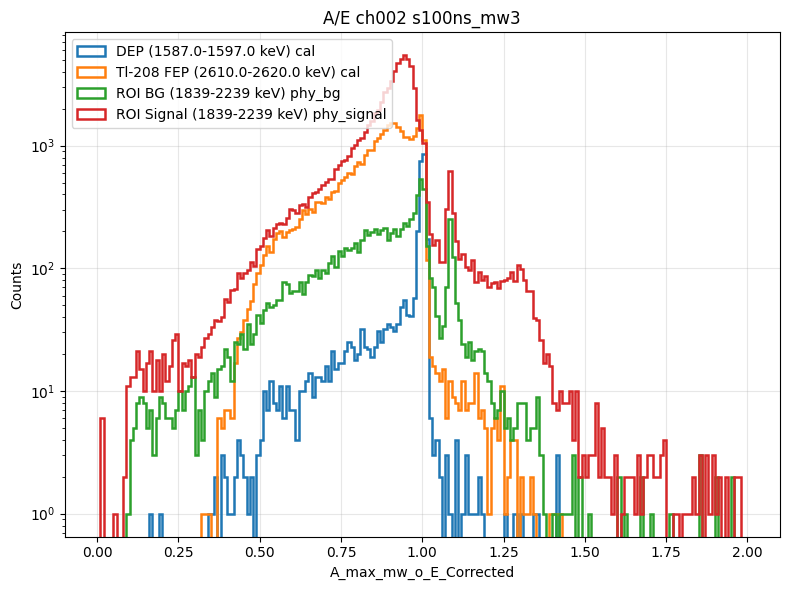

In [51]:
plot_aoe_selections(
    aoe_db,
    mask_db,
    binnum=200,
    aoe_range=(0, 2)
)

## Now we try to understand how much is seperated

In [5]:
import awkward as ak
import gc

def get_field_array_from_file(lh5, group, file, field):
    obj = safe_lh5_read(lh5, group, [file])
    if obj is None:
        return None

    ak_hit = obj.view_as("ak")

    if field not in ak_hit.fields:
        print(f"[ERROR] field '{field}' not found in {file}")
        print("available fields:")
        print(ak_hit.fields)
        del obj, ak_hit
        gc.collect()
        return None

    arr = ak.to_numpy(ak_hit[field]).copy()

    del obj, ak_hit
    gc.collect()
    return arr

In [6]:
def get_group_and_pathlist(info, key):
    mapping = {
        "cal_ch001": ("ch001/hit", info["cal_pathlist"]),
        "cal_ch002": ("ch002/hit", info["cal_pathlist"]),
        "phy_bg_ch001": ("ch001/hit", info["phy_bg_pathlist"]),
        "phy_bg_ch002": ("ch002/hit", info["phy_bg_pathlist"]),
        "phy_signal_ch001": ("ch001/hit", info["phy_signal_pathlist"]),
        "phy_signal_ch002": ("ch002/hit", info["phy_signal_pathlist"]),
    }
    return mapping.get(key, (None, None))

In [7]:
import numpy as np
import gc

def count_low_aoe_for_key(
    info,
    lh5,
    key,
    roi_min=1839,
    roi_max=2239,
    aoe_cut=0.20,
    energy_field="trapEftp_cal",
    aoe_field="A_max_mw_o_E_Corrected",
):
    group, pathlist = get_group_and_pathlist(info, key)

    if group is None:
        print(f"[ERROR] unknown key: {key}")
        return None

    if pathlist is None or len(pathlist) == 0:
        print(f"[ERROR] empty pathlist for {key}")
        return {
            "roi_total": 0,
            "low_aoe_count": 0,
            "fraction": np.nan,
        }

    roi_total = 0
    low_aoe_count = 0

    for file in pathlist:
        E = get_field_array_from_file(lh5, group, file, energy_field)
        aoe = get_field_array_from_file(lh5, group, file, aoe_field)

        if E is None or aoe is None:
            del E, aoe
            gc.collect()
            continue

        roi_mask = (E > roi_min) & (E < roi_max)
        roi_total += np.count_nonzero(roi_mask)
        low_aoe_count += np.count_nonzero(aoe[roi_mask] < aoe_cut)

        del E, aoe, roi_mask
        gc.collect()

    return {
        "roi_total": roi_total,
        "low_aoe_count": low_aoe_count,
        "fraction": low_aoe_count / roi_total if roi_total > 0 else np.nan,
    }

In [8]:
import numpy as np
import gc

def count_low_aoe_in_roi(
    run_db,
    window,
    mw,
    lh5,
    roi_min=1839,
    roi_max=2239,
    aoe_cut=0.20,
    aoe_field="A_max_mw_o_E_Corrected",
    energy_field="trapEftp_cal",
):
    run = f"s{window}_{mw}"

    if run not in run_db:
        print(f"[ERROR] {run} not found")
        return None

    info = run_db[run]
    results = {}

    keys = ["phy_bg_ch001", "phy_bg_ch002", "phy_signal_ch001", "phy_signal_ch002"]

    for key in keys:
        results[key] = count_low_aoe_for_key(
            info,
            lh5,
            key,
            roi_min=roi_min,
            roi_max=roi_max,
            aoe_cut=aoe_cut,
            energy_field=energy_field,
            aoe_field=aoe_field,
        )
        gc.collect()

    return results

In [9]:
import numpy as np
import gc

def count_low_aoe_all_runs(
    run_db,
    lh5,
    roi_min=1839,
    roi_max=2239,
    aoe_cut=0.20,
    energy_field="trapEftp_cal",
    aoe_field="A_max_mw_o_E_Corrected",
):
    summary = {}
    keys = ["phy_bg_ch001", "phy_bg_ch002", "phy_signal_ch001", "phy_signal_ch002"]

    for run, info in run_db.items():
        print(f"processing {run}")
        run_summary = {}

        for key in keys:
            run_summary[key] = count_low_aoe_for_key(
                info,
                lh5,
                key,
                roi_min=roi_min,
                roi_max=roi_max,
                aoe_cut=aoe_cut,
                energy_field=energy_field,
                aoe_field=aoe_field,
            )
            gc.collect()

        summary[run] = run_summary
        del run_summary
        gc.collect()

    return summary

In [13]:
info = run_db["s100ns_mw7"]

res = count_low_aoe_for_key(
    info,
    lh5,
    "phy_signal_ch001",
    roi_min=1839,
    roi_max=2239,
    aoe_cut=0.20,
    energy_field="trapEftp_cal",
    aoe_field="A_max_mw_o_E_Corrected",
)

print(res)

{'roi_total': np.int64(78971), 'low_aoe_count': np.int64(39), 'fraction': np.float64(0.0004938521735827076)}


In [17]:
summary = count_low_aoe_all_runs(run_db, lh5)
print(summary)

processing s100ns_mw1
processing s100ns_mw3
processing s100ns_mw5
processing s100ns_mw7
processing s200ns_mw1
processing s200ns_mw3
processing s200ns_mw5
processing s200ns_mw7
processing s60ns_mw1
processing s60ns_mw3
processing s60ns_mw5
processing s60ns_mw7
{'s100ns_mw1': {'phy_bg_ch001': {'roi_total': np.int64(4710), 'low_aoe_count': np.int64(4), 'fraction': np.float64(0.0008492569002123143)}, 'phy_bg_ch002': {'roi_total': np.int64(9471), 'low_aoe_count': np.int64(44), 'fraction': np.float64(0.004645760743321719)}, 'phy_signal_ch001': {'roi_total': np.int64(78971), 'low_aoe_count': np.int64(19), 'fraction': np.float64(0.00024059464866849856)}, 'phy_signal_ch002': {'roi_total': np.int64(77270), 'low_aoe_count': np.int64(106), 'fraction': np.float64(0.0013718131228160995)}}, 's100ns_mw3': {'phy_bg_ch001': {'roi_total': np.int64(4710), 'low_aoe_count': np.int64(8), 'fraction': np.float64(0.0016985138004246285)}, 'phy_bg_ch002': {'roi_total': np.int64(9471), 'low_aoe_count': np.int64(65

In [16]:
import pickle

def save_summary(summary, filename="summary.pkl"):
    with open(filename, "wb") as f:
        pickle.dump(summary, f)
    print(f"saved to {filename}")

def load_summary(filename="summary.pkl"):
    with open(filename, "rb") as f:
        summary = pickle.load(f)
    print(f"loaded from {filename}")
    return summary
save_summary(res, "res.pkl")
res = load_summary("res.pkl")
res

saved to res.pkl
loaded from res.pkl


{'roi_total': np.int64(78971),
 'low_aoe_count': np.int64(39),
 'fraction': np.float64(0.0004938521735827076)}

In [18]:
save_summary(summary, "my_summary.pkl")

saved to my_summary.pkl


In [19]:
load_summary("my_summary.pkl")

loaded from my_summary.pkl


{'s100ns_mw1': {'phy_bg_ch001': {'roi_total': np.int64(4710),
   'low_aoe_count': np.int64(4),
   'fraction': np.float64(0.0008492569002123143)},
  'phy_bg_ch002': {'roi_total': np.int64(9471),
   'low_aoe_count': np.int64(44),
   'fraction': np.float64(0.004645760743321719)},
  'phy_signal_ch001': {'roi_total': np.int64(78971),
   'low_aoe_count': np.int64(19),
   'fraction': np.float64(0.00024059464866849856)},
  'phy_signal_ch002': {'roi_total': np.int64(77270),
   'low_aoe_count': np.int64(106),
   'fraction': np.float64(0.0013718131228160995)}},
 's100ns_mw3': {'phy_bg_ch001': {'roi_total': np.int64(4710),
   'low_aoe_count': np.int64(8),
   'fraction': np.float64(0.0016985138004246285)},
  'phy_bg_ch002': {'roi_total': np.int64(9471),
   'low_aoe_count': np.int64(65),
   'fraction': np.float64(0.006863055643543448)},
  'phy_signal_ch001': {'roi_total': np.int64(78971),
   'low_aoe_count': np.int64(39),
   'fraction': np.float64(0.0004938521735827076)},
  'phy_signal_ch002': {'roi

In [31]:
for run, run_summary in summary.items():
#     print(f"Run: {run}")
#     for key, result in run_summary.items():
#         print(f"  {key}: {result}")
    low_aoe_count = run_summary.get("phy_signal_ch001").get("low_aoe_count", 0)- run_summary.get("phy_bg_ch001").get("low_aoe_count", 0)
    print(f"  low_aoe_count(<0.20): {low_aoe_count} "+ run.split("_")[1]+ " window=" + run.split("_")[0][1:])

  low_aoe_count(<0.20): 15 mw1 window=100ns
  low_aoe_count(<0.20): 31 mw3 window=100ns
  low_aoe_count(<0.20): 32 mw5 window=100ns
  low_aoe_count(<0.20): 32 mw7 window=100ns
  low_aoe_count(<0.20): 17 mw1 window=200ns
  low_aoe_count(<0.20): 33 mw3 window=200ns
  low_aoe_count(<0.20): 33 mw5 window=200ns
  low_aoe_count(<0.20): 33 mw7 window=200ns
  low_aoe_count(<0.20): 13 mw1 window=60ns
  low_aoe_count(<0.20): 20 mw3 window=60ns
  low_aoe_count(<0.20): 23 mw5 window=60ns
  low_aoe_count(<0.20): 28 mw7 window=60ns
